# TALLER DE ANÁLISIS ESTADÍSTICO DE SEÑALES

### Presentado por: Alma Olea Barbosa - Lauren Cordero Ramos 

### Semestre 2026-2 

### IMPLEMENTACIÓN DE FUNCIONES

In [78]:
# importamos las librerias a utilizar
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import find_peaks
from scipy import stats
from statsmodels.tsa.stattools import adfuller

In [79]:
# Función para calcular RMS
def RMS(N, x):
    suma = 0
    for i in range(N):
        suma += x[i]**2
    rms = np.sqrt(suma/N)
    return rms

### ANÁLISIS ESTADÍSTICO DE ECG

### PUNTO 1
Se determina el tiempo de duración de las señales y se crea un vector tiempo

In [80]:
# se cargan los archivos .mat
data = sio.loadmat('signals.mat') # el archivo tiene que estar en la misma carpeta
print(f"Contenido del archivo: {data}") # se imprime el contenido del archivo para identificar las variables almacenadas y su estructura

fs = int(data['Fs'].flatten()[0]) # extraer frecuencia de muestreo
print(f"\nFrecuencia de muestreo: {fs} Hz")

# se extraen las señales
# se usa .flatten() para convertir la matriz (1,N) en un solo vector de dim 1 y poder manejar más facil las muestras
señal_cruda = data['ECG_asRecording'].flatten()
señal_filtrada = data['ECG_filtered'].flatten()

N= len(señal_cruda) # Número de muestras
print(f"Número de muestras: {N}")

Ts= 1/fs #periodo de muestreo
duracion = N*Ts # duración de la señal en seg
print(f"Duración de la señal: {duracion} segundos")

#se crea el vector tiempo
t = np.arange(0, duracion, Ts)


Contenido del archivo: {'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Apr 20 15:20:29 2015', '__version__': '1.0', '__globals__': [], 'Fs': array([[1024]], dtype=uint16), 'ECG_asRecording': array([[3904.31689453, 3939.203125  , 3976.00683594, ..., 4366.41064453,
        4365.31103516, 4370.91796875]]), 'ECG_filtered': array([[ 8.87103896e-03,  5.62737497e+01,  8.57077127e+01, ...,
        -1.20952610e+02, -1.31734356e+02, -1.32898021e+02]]), 'EMG_filtered1': array([[ 17.65905117,  19.41391578,  18.89666666, ..., 242.49414224,
        220.4135886 , 151.5810508 ]]), 'EMG_filtered2': array([[  21.1780547 ,  -79.82418538, -133.65960989, ..., -384.58994036,
        -539.9349533 , -772.65519631]]), 'EMG_asRecording1': array([[ 908.07531738,  903.17706299,  896.62982178, ..., 1433.91882324,
        1416.109375  , 1352.75012207]]), 'EMG_asRecording2': array([[-3109.97558594, -3231.01391602, -3302.34960938, ...,
        -3791.24267578, -3924.6550293 , -4109.94433594]])

### PUNTO 2

Graficar cruda vs. filtrada, compararlas y explicar qué tipo de filtro se usó

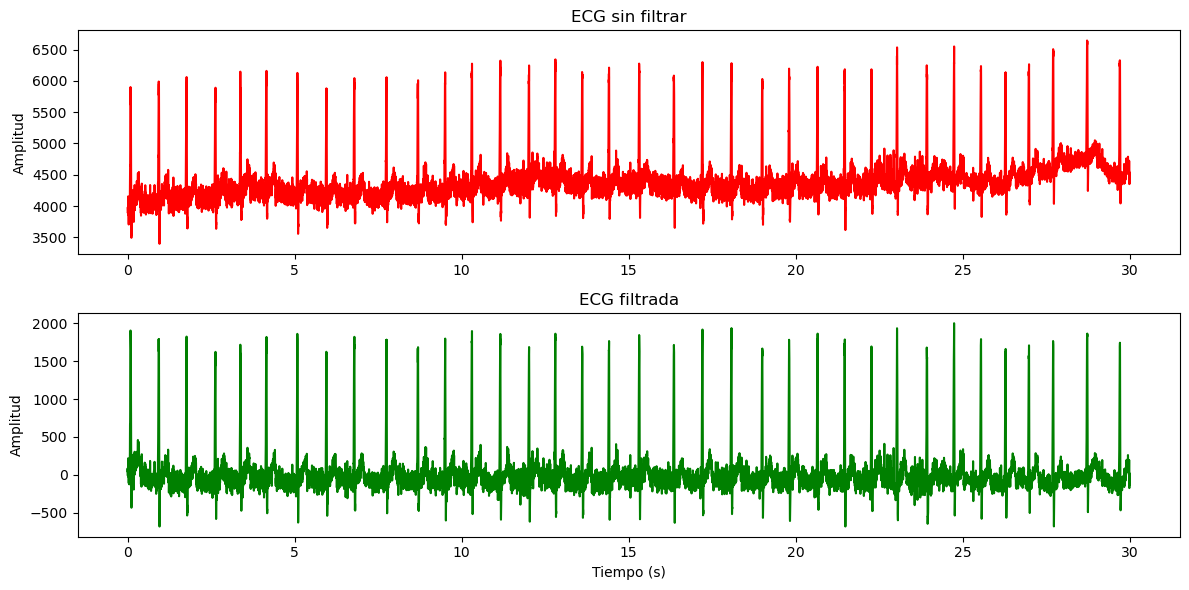

In [81]:
# Se grafica la señal
fig, axs = plt.subplots(2,1, figsize=(12,6))
axs[0].plot(t, señal_cruda, color='red')
axs[0].set_title('ECG sin filtrar')
axs[0].set_ylabel('Amplitud')
axs[1].plot(t, señal_filt, color='green')
axs[1].set_title('ECG filtrada')
axs[1].set_xlabel('Tiempo (s)')
axs[1].set_ylabel('Amplitud')
plt.tight_layout()

En la señal sin filtar se observa que la línea base no es constante, ya que empieza cerca de 4000-4500, se mantiene relativamente estable hasta el segundo 10 y luego sube progresivamente hasta llegar a 4500-5000. Tambien vemos que los picos (latidos) varían un poco en altura a lo largo del registro, al inicio llegan a ~6000 y hacia el final algunos alcanzan ~6500. 

Por otro lado, la señal filtrada su línea base se mantiene estable en 0 durante los 30 segundos completos y la amplitud de los latidos es más uniforme a lo largo de todo el registro (entre ~1600-2000), con esto podemos decir que el filtro eliminó componentes de muy baja frecuencia asociadas a artefactos como el movimiento del sujeto, la respiración o cambios de impedancia en los electrodos, y no a información fisiológica del corazón.Ademas, se observa que los picos (latidos) aparecen exactamente en los mismos instantes de tiempo que en la señal sin filtrar, es decir que tienen el mismo número de latidos y mismo ritmo, esto indica que el filtro no alteró el ritmo cardiaco ni distorsionó la ocurrencia de los latidos.

Con base en estas observaciones, se puede inferir que el filtro utilizado corresponde a un filtro pasa-altas con frecuencia de corte baja (posiblemente cercana a 0.5 Hz), cuyo objetivo es remover el offset DC y la deriva de línea base, conservando las frecuencias de interés del ECG (aproximadamente entre 0.5 Hz y 40-150 Hz, donde se concentran las ondas P, QRS y T) (Wesolowski et al., 2023).

#### PUNTO 3

Tomar la señal cruda, graficar un ciclo cardiaco (un latido), y calcular su promedio, RMS, varianza y desviación estándar.

Nota: Este punto se puede hacer de dos maneras: una opción es al 'ojo', es decir, elegir dónde empieza un ciclo y dónde termina el otro, mientras que otra forma es usar la función find_peaks() para detectar los picos  R y asi poder identidicar con mayor precisión cada ciclo. 
Para esta segunda opción, la función find_peaks() se debe aplicar a la señal filtrada, ya que es más limpia por lo que se puede identificar los picos R sin confundirlo con ruido 

Número de picos detectados: 36


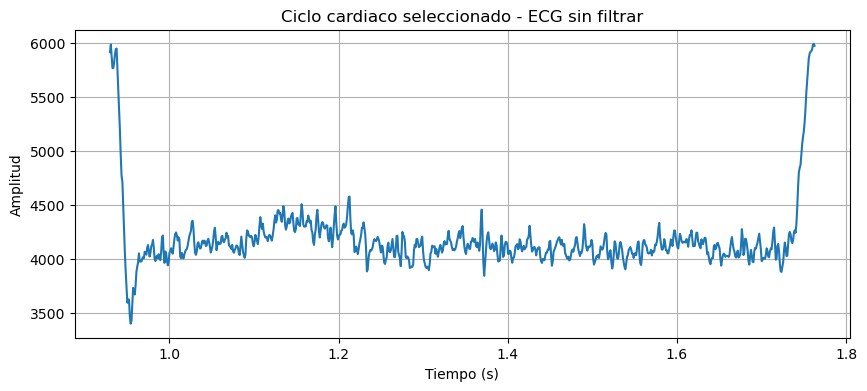

In [82]:
# Buscamos los picos R en la señal filtrada (es más limpia, mejor para detectar)
# height=800 -> solo cuenta picos con amplitud mayor a 800 para evitar que tome picos equivocados
# distance=0.4*Fs -> los picos deben estar separados al menos 0.4 segundos (un corazón normal no late más rápido que cada 0.4s, o sea, max 150 lpm)
picos, _ = find_peaks(señal_filt, height=800, distance=int(0.4*fs))

print("Número de picos detectados:", len(picos))

# Tomamos el ciclo entre el segundo pico y el tercero
inicio = picos[1]
fin = picos[2]

t_ciclo = t[inicio:fin] # instante de tiempo donde empieza y termina el ciclo que selecionamos
ciclo_sinfiltrar = señal_cruda[inicio:fin] # instante donde empieza y termina la señal

# Graficamos
plt.figure(figsize=(10,4))
plt.plot(t_ciclo, ciclo_sinfiltrar)
plt.title('Ciclo cardiaco seleccionado - ECG sin filtrar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

In [83]:
N1 = len(ciclo_sinfiltrar)  # número de muestras del ciclo

promedio1= np.mean(ciclo_sinfiltrar)
rms1 = RMS(N1, ciclo_sinfiltrar)   # tu función de la parte 1
varianza1= np.var(ciclo_sinfiltrar)
desv1 = np.std(ciclo_sinfiltrar)

print(f"Promedio de la señal sin filtrar: {promedio1}")
print(f"RMS de la señal sin filtrar: {rms1}")
print(f"Varianza de la señal sin filtrar: {varianza1}")
print(f"Desviación estándar de la señal sin filtrar: {desv1}")

Promedio de la señal sin filtrar: 4185.590964109613
RMS de la señal sin filtrar: 4198.137633330678
Varianza de la señal sin filtrar: 105187.8695513509
Desviación estándar de la señal sin filtrar: 324.3267943777555


El promedio ≈4185 y el RMS ≈4198 de la señal sin filtrar son muy altos y muy parecidos entre sí, porque la señal cruda tiene un offset DC (no está centrada en cero) este offset domina el valor de ambos estadísticos. La varianza (≈105187) y la desviación estándar (≈324) reflejan qué tan dispersos están los valores del ciclo respecto a su propio promedio, es decir, la "amplitud real" de la variación del latido, independientemente de dónde esté centrada la señal.

#### PUNTO 4

Repetir lo mismo con la señal filtrada

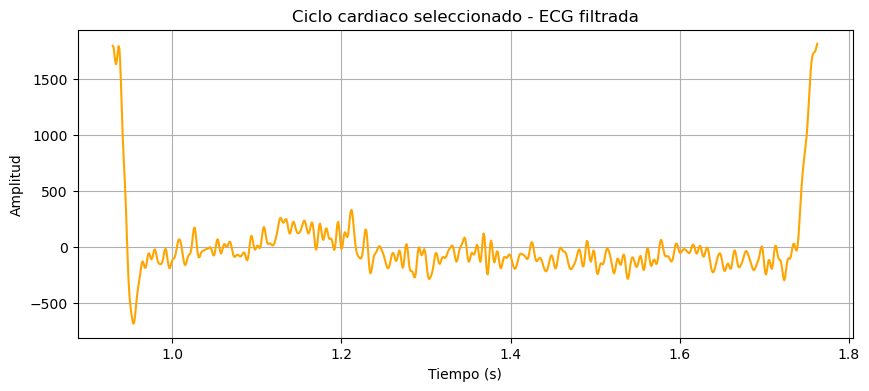

In [84]:
ciclo_filtrada = señal_filt[inicio:fin]

# Graficamos
plt.figure(figsize=(10,4))
plt.plot(t_ciclo, ciclo_filtrada, color='orange')
plt.title('Ciclo cardiaco seleccionado - ECG filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

In [85]:
N2= len(ciclo_filtrada)
# Estadísticos del ciclo filtrado
promedio_filt = np.mean(ciclo_filtrada)
rms_filt = RMS(N2, ciclo_filtrada)
varianza_filt = np.var(ciclo_filtrada)
desv_filt = np.std(ciclo_filtrada)

print(f"Promedio de la señal filtrada: {promedio_filt}")
print(f"RMS de la señal filtrada: {rms_filt}")
print(f"Varianza de la señal filtrada: {varianza_filt}")
print(f"Desviación estándar de la señal filtrada: {desv_filt}")

Promedio de la señal filtrada: -1.4625781779933433
RMS de la señal filtrada: 323.7168587274148
Varianza de la señal filtrada: 104790.46548941819
Desviación estándar de la señal filtrada: 323.7135546890463


Al comparar los estadísticos del mismo ciclo cardiaco antes y después del filtrado, se observa que el promedio cambia drásticamente: de 4185.59 en la señal sin filtrar a -1.46 en la filtrada. Esto confirma que el filtro eliminó el offset DC presente en la señal original (un nivel constante cercano a 4185 que no aporta información fisiológica), dejando la señal filtrada prácticamente centrada en cero. Por otra parte, el RMS cae de 4198.14 a 323.72, esto ocurre porque el RMS al elevar cada muestra al cuadrado, es muy sensible a un offset grande: en la señal sin filtrar su valor está casi por completo por ese offset (por eso es tan parecido al promedio), y no refleja la verdadera energía de la variación del latido. En la señal filtrada, al no existir offset, el RMS sí representa fielmente la magnitud real de las oscilaciones del ciclo cardiaco. Ademas, la varianza (105187.87 vs. 104790.47) y la desviación estándar (324.33 vs. 323.71) son muy parecidas entre ambas señales, esto es coherente con la teoría, ya que estas medidas describen la dispersión de los datos respecto a su propia media, por lo que no se ven afectadas por el offset, lo que importa es qué tan lejos está cada muestra de su propio promedio.

Y como lo mencionamos anteriormente, este comportamiento es consistente con un filtro pasa-altas, ya que remueve el offset DC y la deriva de línea base, sin alterar significativamente la forma ni la energía relativa del latido cardiaco.

#### PUNTO 5

Extraer 15 ciclos de la señal filtrada, calcular promedio y varianza de cada uno, graficarlos todos, evaluar si parecen estadísticamente similares y analizar si se puede considerar como una señal estacionaria

In [86]:
# Extraemos 15 ciclos consecutivos de la señal filtrada
# Acá usamos entonces los picos R detectados anteriormente (picos[1] hasta picos[16])
numero_ciclos = 15
ciclos_filtrada = []
promedios_ciclos = []
varianzas_ciclos = []

for i in range(1, 1 + numero_ciclos):
    picos, _ = find_peaks(señal_filt, height=800, distance=int(0.4*fs))
    ini = picos[i]
    fn = picos[i+1]
    ciclonuevo = señal_filt[ini:fn]
    ciclos_filtrada.append(ciclonuevo)
    promedios_ciclos.append(np.mean(ciclonuevo))
    varianzas_ciclos.append(np.var(ciclonuevo))

promedios_ciclos = np.array(promedios_ciclos)
varianzas_ciclos = np.array(varianzas_ciclos)

for i in range(numero_ciclos):
    print(f"Ciclo {i+1}: promedio = {promedios_ciclos[i]:.2f}, varianza = {varianzas_ciclos[i]:.2f}")

print(f"\nMedia de los promedios: {np.mean(promedios_ciclos):.2f}  |  Desv. estándar de los promedios: {np.std(promedios_ciclos):.2f}")
print(f"Media de las varianzas: {np.mean(varianzas_ciclos):.2f}  |  Desv. estándar de las varianzas: {np.std(varianzas_ciclos):.2f}")


Ciclo 1: promedio = -1.46, varianza = 104790.47
Ciclo 2: promedio = -10.43, varianza = 82451.25
Ciclo 3: promedio = -20.98, varianza = 46839.02
Ciclo 4: promedio = 40.87, varianza = 114850.02
Ciclo 5: promedio = -27.94, varianza = 58147.59
Ciclo 6: promedio = 0.43, varianza = 77707.28
Ciclo 7: promedio = 21.41, varianza = 100268.18
Ciclo 8: promedio = -10.18, varianza = 71784.96
Ciclo 9: promedio = 8.81, varianza = 68481.06
Ciclo 10: promedio = -8.91, varianza = 76088.38
Ciclo 11: promedio = 13.21, varianza = 93862.70
Ciclo 12: promedio = -4.20, varianza = 87951.50
Ciclo 13: promedio = -14.97, varianza = 77022.13
Ciclo 14: promedio = 27.11, varianza = 89636.94
Ciclo 15: promedio = -22.36, varianza = 57497.80

Media de los promedios: -0.64  |  Desv. estándar de los promedios: 18.91
Media de las varianzas: 80491.95  |  Desv. estándar de las varianzas: 18080.68


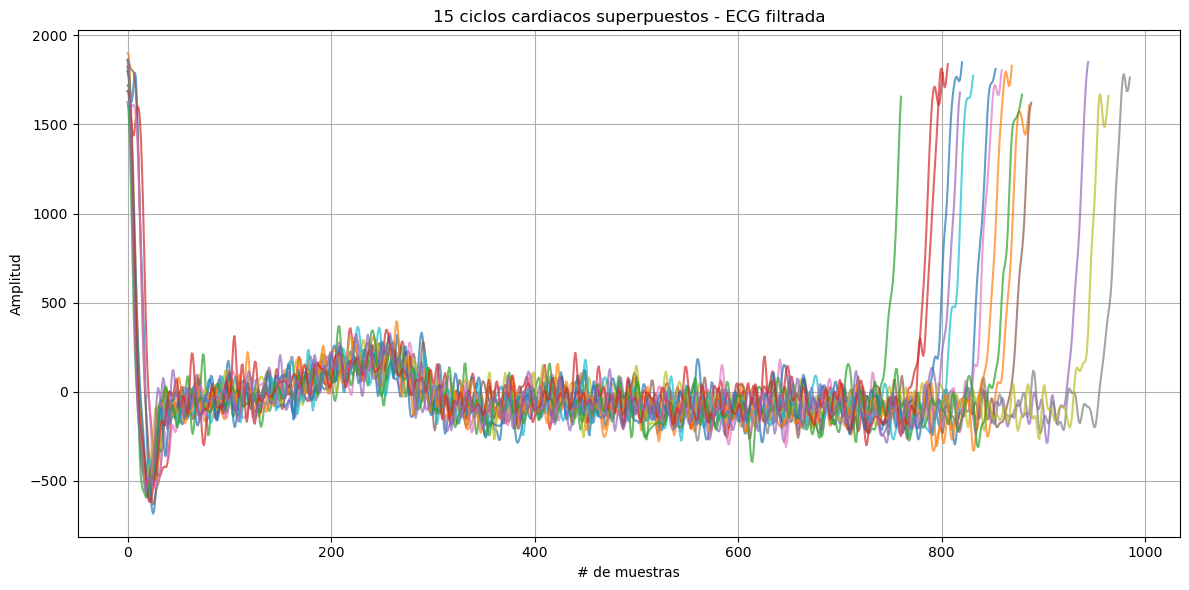

In [87]:
# Graficamos los 15 ciclos 
plt.figure(figsize=(12,6))
for i, ciclo in enumerate(ciclos_filtrada):
    plt.plot(ciclo, alpha=0.7, label=f'Ciclo {i+1}')
plt.title('15 ciclos cardiacos superpuestos - ECG filtrada')
plt.xlabel('# de muestras')
plt.ylabel('Amplitud')
plt.grid()
plt.tight_layout()
plt.show()

Al superponer los 15 ciclos, podemos observar una morfología similar en todos estos, con estructuras características del ECG, como el complejo QRS y las ondas P y T, ubicadas aproximadamente en la misma posición. Los promedios de los ciclos varían entre aproximadamente -28 y 41, pero no presentan una tendencia de aumento o disminución. En cambio, fluctúan alrededor de cero, con una media general cercana a -0.64. Por otro lado, las varianzas se mantienen en un rango relativamente similar, lo que indica que la dispersión de la señal no presenta cambios abruptos entre los diferentes ciclos.

De cierta manera, desde la observación y el análisis, estos resultados nos muestran que la señal es aproximadamente estacionaria durante los 30 segundos analizados.

#### PUNTO 6

Comparar dos pares de ciclos con prueba t, pero antes verificando los supuestos:
Normalidad (ej. Shapiro-Wilk)
Independencia (se asume)
Homocedasticidad (prueba de Levene)
Si no se cumplen los supuestos, usar la alternativa no paramétrica: U de Mann-Whitney.

In [88]:
# Función para evaluar los supuestos y aplicar la prueba correspondiente

def comparar_ciclos(c1, c2, nombre1, nombre2):
    print(f"--- Comparación: {nombre1} vs {nombre2} ---")

    # 1) Prueba de normalidad (Shapiro-Wilk) para cada ciclo
    shp1 = stats.shapiro(c1)
    shp2 = stats.shapiro(c2)
    print(f"Shapiro-Wilk {nombre1}: estadístico={shp1.statistic:.4f}, p-value={shp1.pvalue:.4g}")
    print(f"Shapiro-Wilk {nombre2}: estadístico={shp2.statistic:.4f}, p-value={shp2.pvalue:.4g}")
    normalidad = (shp1.pvalue > 0.05) and (shp2.pvalue > 0.05)

    # 2) Prueba de homocedasticidad (Levene)
    levn = stats.levene(c1, c2)
    print(f"Levene: estadístico={levn.statistic:.4f}, p-value={levn.pvalue:.4g}")
    homocedasticidad = levn.pvalue > 0.05

    print(f"¿Se cumple la normalidad?: {normalidad}   |   ¿Se cumple la homocedasticidad?: {homocedasticidad}")


    # 4) Prueba de hipótesis según se cumplan o no los supuestos
    if normalidad:
        tt = stats.ttest_ind(c1, c2, equal_var=homocedasticidad)
        print(f"Se cumple normalidad -> prueba t de Student (equal_var={homocedasticidad})")
        print(f"t-test: estadístico={tt.statistic:.4f}, p-value={tt.pvalue:.4g}")
        p = tt.pvalue
    else:
        mw = stats.mannwhitneyu(c1, c2, alternative='two-sided')
        print("No se cumple normalidad -> prueba no paramétrica U de Mann-Whitney")
        print(f"Mann-Whitney U: estadístico={mw.statistic:.4f}, p-value={mw.pvalue:.4g}")
        p = mw.pvalue

    if p < 0.05:
        print(f"Conclusión: p = {p:.4g} < 0.05 -> SÍ hay diferencia estadísticamente significativa entre los ciclos.")
    else:
        print(f"Conclusión: p = {p:.4g} >= 0.05 -> NO hay evidencia de diferencia estadísticamente significativa entre los ciclos.")
    print()
    return p


In [89]:
# Comparación 1: ciclo 1 vs ciclo 5
p1 = comparar_ciclos(ciclos_filtrada[0], ciclos_filtrada[4], "Ciclo 1", "Ciclo 5")


--- Comparación: Ciclo 1 vs Ciclo 5 ---
Shapiro-Wilk Ciclo 1: estadístico=0.5503, p-value=4.438e-42
Shapiro-Wilk Ciclo 5: estadístico=0.5638, p-value=2.516e-43
Levene: estadístico=7.6690, p-value=0.005675
¿Se cumple la normalidad?: False   |   ¿Se cumple la homocedasticidad?: False
No se cumple normalidad -> prueba no paramétrica U de Mann-Whitney
Mann-Whitney U: estadístico=411664.0000, p-value=0.4589
Conclusión: p = 0.4589 >= 0.05 -> NO hay evidencia de diferencia estadísticamente significativa entre los ciclos.



In [90]:
# Comparación 1: ciclo 2 vs ciclo 15
p1 = comparar_ciclos(ciclos_filtrada[1], ciclos_filtrada[14], "Ciclo 2", "Ciclo 15")


--- Comparación: Ciclo 2 vs Ciclo 15 ---
Shapiro-Wilk Ciclo 2: estadístico=0.5641, p-value=2.975e-42
Shapiro-Wilk Ciclo 15: estadístico=0.6219, p-value=6.215e-39
Levene: estadístico=1.3529, p-value=0.2449
¿Se cumple la normalidad?: False   |   ¿Se cumple la homocedasticidad?: True
No se cumple normalidad -> prueba no paramétrica U de Mann-Whitney
Mann-Whitney U: estadístico=360385.0000, p-value=0.7799
Conclusión: p = 0.7799 >= 0.05 -> NO hay evidencia de diferencia estadísticamente significativa entre los ciclos.



A partir de la prueba de Shapiro-Wilk pudimos ver que los ciclos analizados no cumplen el supuesto de normalidad (p << 0.05), por lo que se aplicó la prueba no paramétrica U de Mann-Whitney. En ambas comparaciones (ciclo 1 vs ciclo 5 y ciclo 2 vs ciclo 15) se obtuvieron valores de p > 0.05 (p ≈ 0.459 y p ≈ 0.78), indicando que no existen diferencias estadísticamente significativas entre los ciclos comparados.

Estos resultados obtenidos respaldan la hipótesis de que las propiedades estadísticas de la señal se mantienen estables a lo largo del registro y, por tanto, respaldan su comportamiento aproximadamente estacionario. Aunque la prueba de Levene presentó resultados mixtos, esto puede atribuirse a la variabilidad natural entre latidos del corazón.


#### PUNTO 7

Confirmar la estacionariedad con la prueba de Dickey-Fuller

In [91]:
# Aplicamos la prueba de Dickey-Fuller aumentada (ADF) a la señal filtrada completa. 
# Se usa la prueba en versión porque la señal de ECG tiene fuerte autocorrelación y se debe incluir este supuesto.
                                                    
resultado_adf = adfuller(señal_filtrada)

print('ADF Statistic: %f' % resultado_adf[0])
print('p-value: %f' % resultado_adf[1])
print('Valores críticos:')
for clave, valor in resultado_adf[4].items():
    print(f'   {clave}: {valor:.4f}')

ADF Statistic: -23.311123
p-value: 0.000000
Valores críticos:
   1%: -3.4306
   5%: -2.8616
   10%: -2.5668


La prueba ADF obtuvo un estadístico de -27.93 y un p-value < 0.05, por lo que se rechaza la hipótesis nula de no estacionariedad. En consecuencia, la señal ECG filtrada se considera estadísticamente estacionaria durante los 30 segundos analizados.

Este resultado coincide con lo observado anteriormente, donde los promedios, varianzas y comparaciones entre ciclos no mostraron cambios significativos. Por tanto, la señal puede tratarse como estacionaria bajo las condiciones de este registro.


#### CONCLUSIONES

- A lo largo del taller se evidenció la importancia del preprocesamiento de una señal ECG. El filtrado permitió eliminar el offset DC y las variaciones de la línea base, obteniendo una señal más estable y uniforme.

- El análisis de los ciclos mostró que sus promedios y varianzas no presentan tendencias significativas a lo largo del registro. Esto fue respaldado mediante la prueba U de Mann-Whitney y, finalmente, por la prueba ADF, que confirmó estadísticamente la estacionariedad de la señal.

- Por último, los resultados indican que bajo las condiciones del experimento y durante los 30 segundos analizados, la señal ECG filtrada puede considerarse aproximadamente estacionaria. Esta conclusión es específica para el registro estudiado, ya que cambios en el tiempo de adquisición o en el estado fisiológico del sujeto podrían modificar este comportamiento.


#### REFERENCIAS

Wesolowski, A., Zheng, D., & Nowak, A. (2023). Exploring Best Practices for ECG Pre-Processing in Machine Learning. arXiv preprint arXiv:2311.04229.

Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *Journal of the American Statistical Association, 74*(366a), 427-431.

Levene, H. (1960). Robust tests for equality of variances. En I. Olkin (Ed.), *Contributions to Probability and Statistics: Essays in Honor of Harold Hotelling* (pp. 278-292). Stanford University Press.

Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *The Annals of Mathematical Statistics, 18*(1), 50-60.

Shapiro, S. S., & Wilk, M. B. (1965). An analysis of variance test for normality (complete samples). *Biometrika, 52*(3/4), 591-611.

Goldberger, A. L., Goldberger, Z. D., & Shvilkin, A. (2023). *Goldberger's Clinical Electrocardiography: A Simplified Approach* (10th ed.). Elsevier.